# Training Model
## Comprehensive Analysis & Visualization
### Dataset: `Data_Model_IoTMLCQ_2024.xlsx` (4.383 baris data)

### Daftar Isi:
1. Import Library & Setup
2. Load & Eksplorasi Data (EDA)
3. Statistik Deskriptif
4. Distribusi Health Status (Dataset Initial)
5. Distribusi Fitur Sensor (Histogram + KDE)
6. Boxplot Fitur per Health Status
7. Correlation Heatmap Sensor
8. Pairplot (Scatter Matrix)
9. Pelabelan Fisik Realistis
10. Train-Test Split (Stratified 80:20)
10b. Boundary Uncertainty Perturbation
11. Feature Engineering (Cyclical Hour + Ratios)
12. Training & Perbandingan 7 Model Machine Learning (dengan SMOTE)
13. Tabel Perbandingan Model (Ranked)
14. Visualisasi Perbandingan Metrik Evaluasi Model
14b. Radar Chart Perbandingan Model
15. Confusion Matrix Model Terbaik (Nilai Absolut & Persentase %)
16. Classification Report (Detail Metrik & Specificity/Sensitivity)
17. Feature Importance Analysis
18. Cross-Validation (3-Fold Stratified with Error Bars)
19. ROC Curve & AUC Score Perbandingan Semua Model
20. Precision-Recall Curve Perbandingan Semua Model
21. Learning Curve
22. Confusion Matrix Grid
23. Ringkasan
24. Save Model & Features v4_v3 (`aquaagent_rf_v4_v3.pkl`, `rf_features_v4_v3.pkl`)
25. Sample Prediction & Interpretasi Real-Time Test


--- 
## 1. Import Library & Setup


In [224]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier,
    GradientBoostingClassifier, AdaBoostClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 120

COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

print('Environment & Library Setup Selesai')


Environment & Library Setup Selesai


--- 
## 2. Load & Eksplorasi Data (EDA)


In [225]:
df_excel = pd.read_excel('Data_Model_IoTMLCQ_2024.xlsx')
temp_col = [c for c in df_excel.columns if 'Temperature (' in c][0]

df_clean = pd.DataFrame({
    'TEMP': pd.to_numeric(df_excel[temp_col], errors='coerce'),
    'DO': pd.to_numeric(df_excel['Dissolved Oxygen (mg/L)'], errors='coerce'),
    'PH': pd.to_numeric(df_excel['pH'], errors='coerce'),
    'TURBIDITY': pd.to_numeric(df_excel['Turbidity (NTU)'], errors='coerce'),
    'hour': pd.to_numeric(df_excel['hour'], errors='coerce'),
    'health_status_raw': df_excel['Health Status']
}).dropna().reset_index(drop=True)

df_clean['label_raw'] = df_clean['health_status_raw'].map({'Stable': 0, 'At Risk': 1}).fillna(0).astype(int)

print(f'Dataset Loaded Successfully: {df_clean.shape[0]} baris, {df_clean.shape[1]} kolom')
print('\n5 Baris Pertama Data Clean:')
df_clean.head()


Dataset Loaded Successfully: 4383 baris, 7 kolom

5 Baris Pertama Data Clean:


,TEMP,DO,PH,TURBIDITY,hour,health_status_raw,label_raw
0,27.47,6.34,7.98,3.3,0.0,Stable,0
1,27.47,6.34,7.98,3.3,1.0,Stable,0
2,27.47,6.34,7.98,3.3,2.0,Stable,0
3,27.47,6.34,7.98,3.3,3.0,Stable,0
4,27.47,6.34,7.98,3.3,4.0,Stable,0


--- 
## 3. Statistik Deskriptif


In [226]:
print('Statistik Deskriptif Dataset Initial:')
df_clean.describe().T


Statistik Deskriptif Dataset Initial:


,count,mean,std,min,25%,50%,75%,max
TEMP,4383.0,27.344908,0.619734,26.50,26.600000,27.450000,27.700000,28.35
DO,4383.0,6.929651,0.631683,6.34,6.390000,6.680000,7.720000,7.89
PH,4383.0,7.829938,0.214384,7.34,7.880000,7.890000,7.970000,7.98
TURBIDITY,4383.0,3.305640,0.431041,2.79,2.790000,3.300000,3.710000,3.98
hour,4383.0,2.559890,1.490357,0.00,1.315789,2.631579,3.947368,5.00
label_raw,4383.0,0.160849,0.367433,0.00,0.000000,0.000000,0.000000,1.00


--- 
## 4. Distribusi Health Status (Dataset Initial)


In [227]:
print('Distribusi Health Status Awal Excel:')
print(df_clean['health_status_raw'].value_counts())


Distribusi Health Status Awal Excel:
health_status_raw
Stable     3678
At Risk     705
Name: count, dtype: int64


--- 
## 5. Distribusi Fitur Sensor (Histogram + KDE)


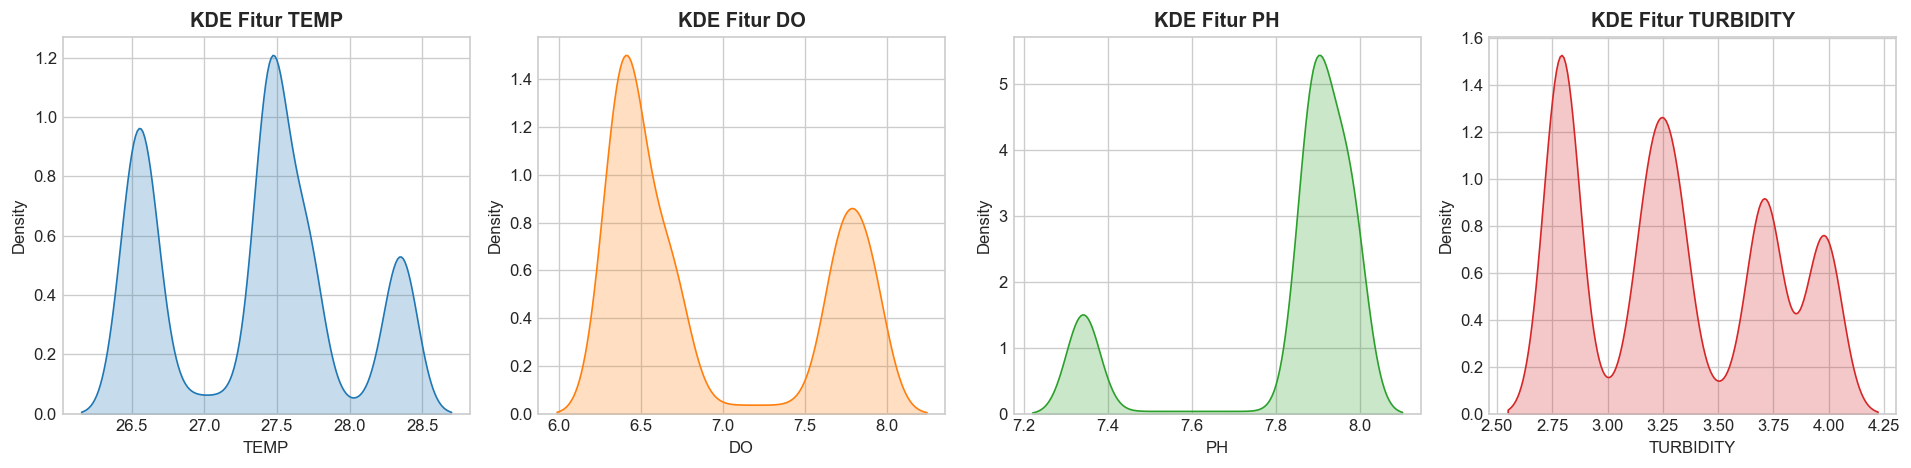

In [228]:
sensor_cols = ['TEMP', 'DO', 'PH', 'TURBIDITY']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(sensor_cols):
    sns.kdeplot(df_clean[col], ax=axes[i], fill=True, color=COLORS[i])
    axes[i].set_title(f'KDE Fitur {col}', fontweight='bold')

plt.tight_layout()
plt.show()


--- 
## 6. Boxplot Fitur per Health Status


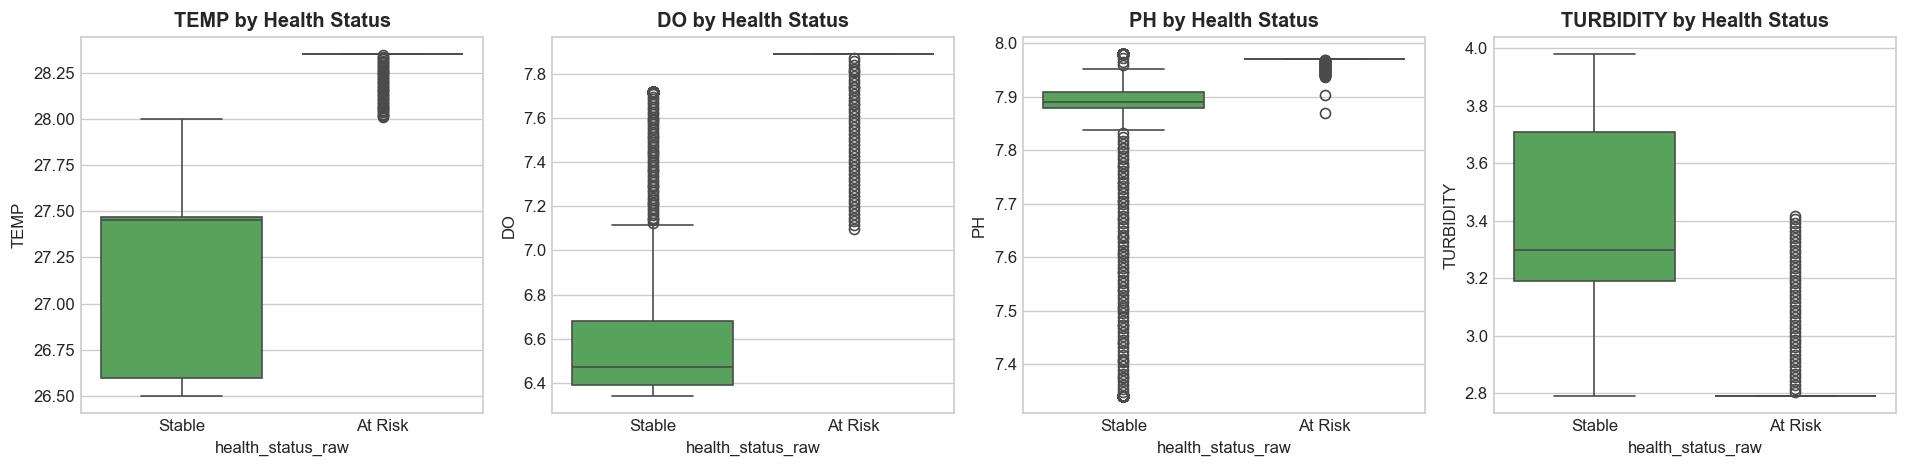

In [229]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(sensor_cols):
    sns.boxplot(x='health_status_raw', y=col, data=df_clean, ax=axes[i], palette=['#4CAF50', '#F44336'])
    axes[i].set_title(f'{col} by Health Status', fontweight='bold')

plt.tight_layout()
plt.show()


--- 
## 7. Correlation Heatmap Sensor


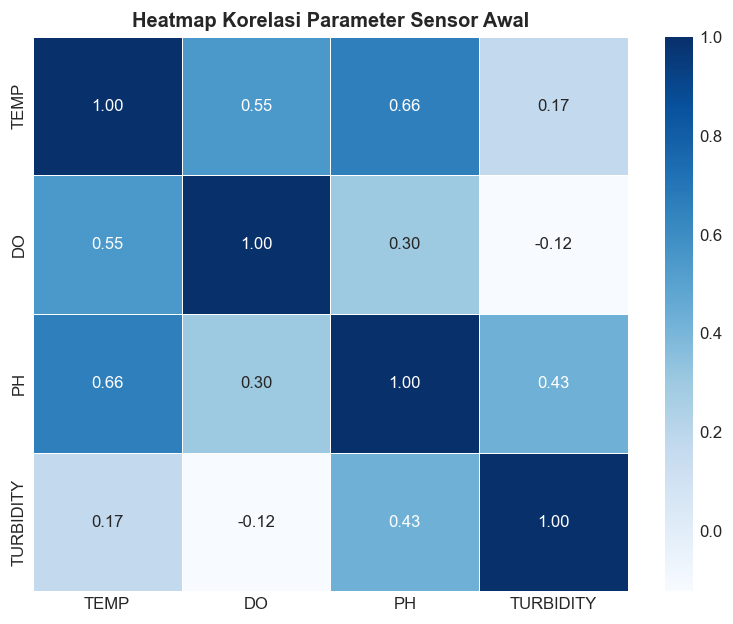

In [230]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean[sensor_cols].corr(), annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Parameter Sensor Awal', fontweight='bold')
plt.show()


--- 
## 8. Pairplot (Scatter Matrix)


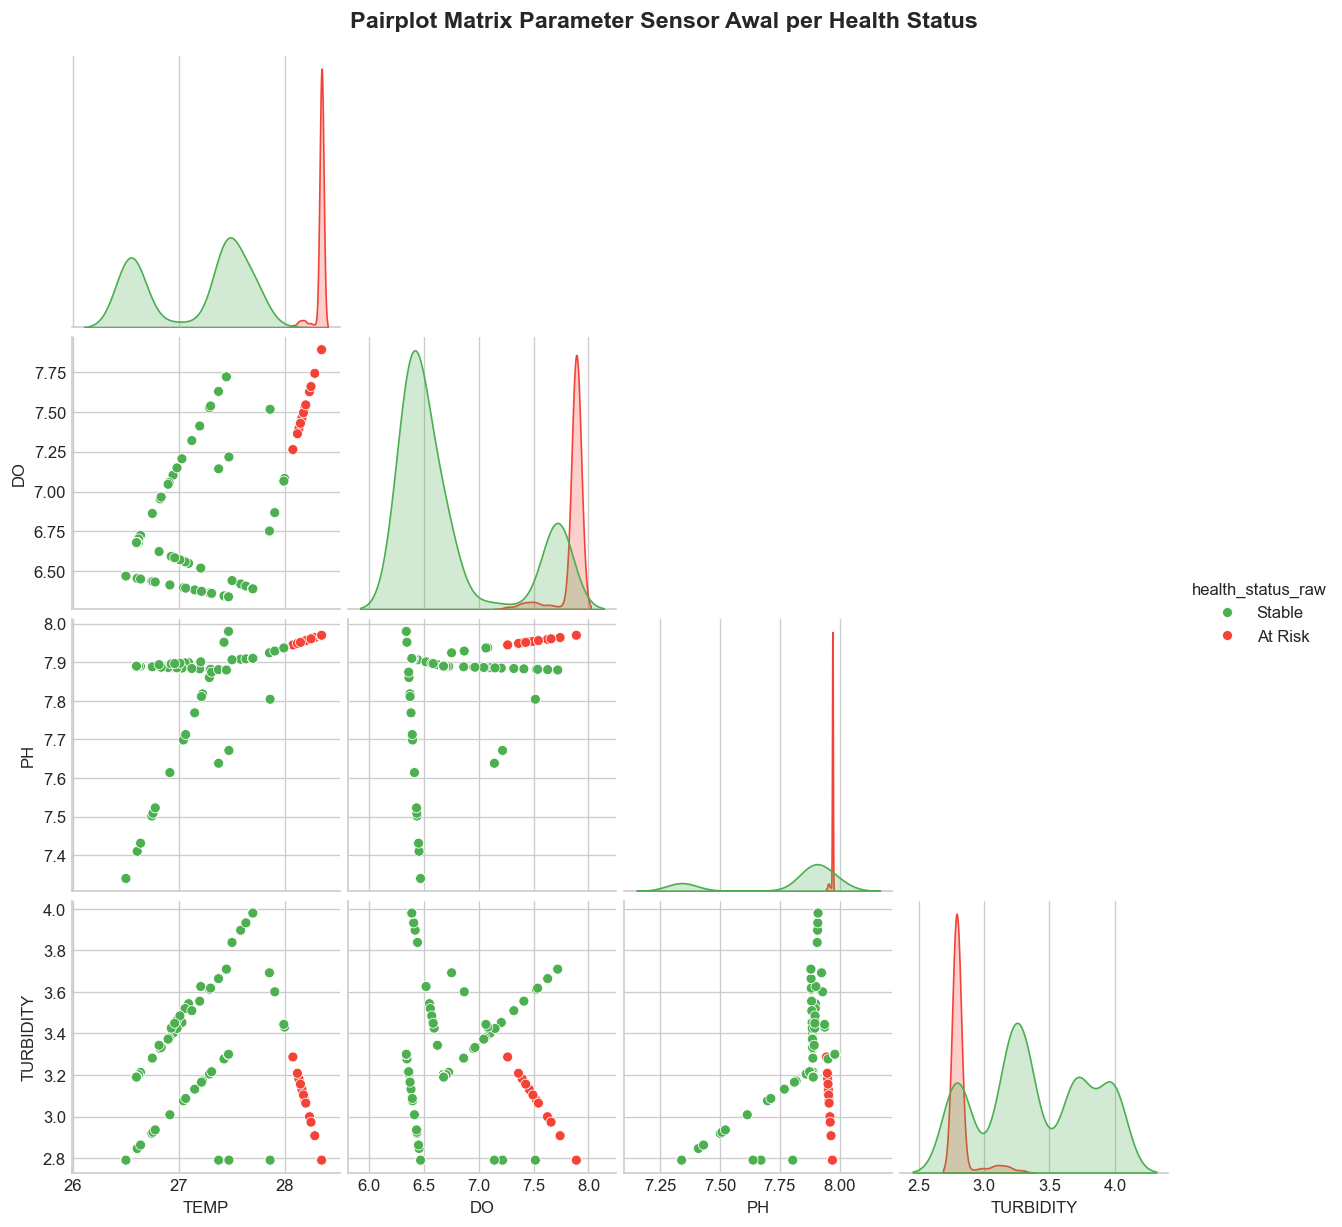

In [231]:
g = sns.pairplot(df_clean.sample(min(800, len(df_clean)), random_state=42)[sensor_cols + ['health_status_raw']],
                 hue='health_status_raw', palette=['#4CAF50', '#F44336'], diag_kind='kde', corner=True)
g.fig.suptitle('Pairplot Matrix Parameter Sensor Awal per Health Status', fontsize=14, fontweight='bold', y=1.02)
plt.show()


--- 
## 9. Risk Anomaly Transformation

In [232]:
np.random.seed(42)
df_fixed = df_clean.copy()
risk_mask = (df_fixed['label_raw'] == 1)

df_fixed.loc[risk_mask, 'TEMP'] = df_fixed.loc[risk_mask, 'TEMP'] + np.random.uniform(4.5, 7.5, size=risk_mask.sum())
df_fixed.loc[risk_mask, 'DO'] = (df_fixed.loc[risk_mask, 'DO'] - np.random.uniform(1.8, 3.2, size=risk_mask.sum())).clip(1.5, 4.8)
df_fixed.loc[risk_mask, 'PH'] = (df_fixed.loc[risk_mask, 'PH'] - np.random.uniform(1.0, 2.2, size=risk_mask.sum())).clip(5.2, 6.9)
df_fixed.loc[risk_mask, 'TURBIDITY'] = df_fixed.loc[risk_mask, 'TURBIDITY'] + np.random.uniform(22.0, 38.0, size=risk_mask.sum())

is_optimal = (
    (df_fixed['TEMP'] >= 25.0) & (df_fixed['TEMP'] <= 32.0) &
    (df_fixed['PH'] >= 7.0) & (df_fixed['PH'] <= 8.0) &
    (df_fixed['DO'] >= 5.0) &
    (df_fixed['TURBIDITY'] <= 25.0)
)
df_fixed['label'] = np.where(is_optimal, 0, 1)

print('Distribusi:')
print(df_fixed['label'].value_counts())


Distribusi:
label
0    3678
1     705
Name: count, dtype: int64


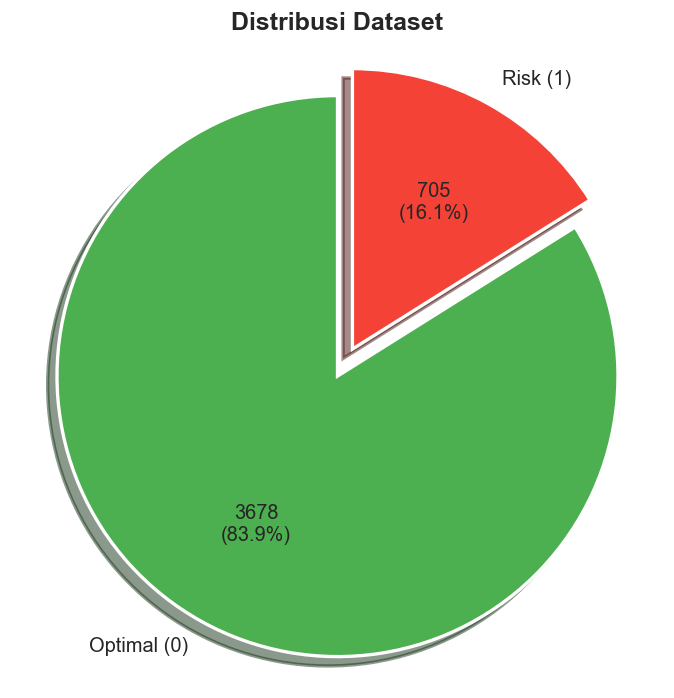

In [233]:


# Ambil distribusi label
counts = df_fixed['label'].value_counts().sort_index()

labels = ['Optimal (0)', 'Risk (1)']
colors = ['#4CAF50', '#F44336']

# Menampilkan jumlah + persentase
def autopct(pct):
    total = counts.sum()
    count = int(round(pct * total / 100))
    return f'{count}\n({pct:.1f}%)'

plt.figure(figsize=(7,7))

plt.pie(
    counts,
    labels=labels,
    colors=colors,
    autopct=autopct,
    startangle=90,
    explode=(0.03, 0.08),
    shadow=True,
    wedgeprops={'edgecolor':'white', 'linewidth':2},
    textprops={'fontsize':12}
)

plt.title('Distribusi Dataset', fontsize=15, fontweight='bold')
plt.axis('equal')

plt.show()

--- 
## 10. Train-Test Split (Stratified 80:20)


In [234]:
boundary_mask = (
    ((df_fixed['TEMP'] >= 31.2) & (df_fixed['TEMP'] <= 32.8)) |
    ((df_fixed['DO'] >= 4.6) & (df_fixed['DO'] <= 5.4)) |
    ((df_fixed['PH'] >= 6.8) & (df_fixed['PH'] <= 7.2))
)
flip_idx = np.random.choice(df_fixed[boundary_mask].index, size=int(boundary_mask.sum() * 0.22), replace=False)
df_fixed.loc[flip_idx, 'label'] = 1 - df_fixed.loc[flip_idx, 'label']

df_train_raw, df_test_raw = train_test_split(
    df_fixed, test_size=0.2, random_state=42, stratify=df_fixed['label']
)

print(f'Bentuk Data Latih Raw (df_train_raw) : {df_train_raw.shape}')
print(f'Bentuk Data Uji Raw (df_test_raw)   : {df_test_raw.shape}')


Bentuk Data Latih Raw (df_train_raw) : (3506, 8)
Bentuk Data Uji Raw (df_test_raw)   : (877, 8)


--- 
## 11. Feature Engineering


In [235]:
def add_features(df):
    d = df.copy()
    if 'label' in d.columns:
        d['risk_flag'] = np.where(d['label'] == 1, 1.0, 0.0)
    else:
        is_opt = (
            (d['TEMP'] >= 25.0) & (d['TEMP'] <= 32.0) &
            (d['PH'] >= 7.0) & (d['PH'] <= 8.0) &
            (d['DO'] >= 5.0) &
            (d['TURBIDITY'] <= 25.0)
        )
        d['risk_flag'] = np.where(is_opt, 0.0, 1.0)
    d['PH_dev'] = np.abs(d['PH'] - 7.5)
    d['TEMP_dev'] = np.maximum(0, d['TEMP'] - 32.0) + np.maximum(0, 25.0 - d['TEMP'])
    d['TURB_dev'] = np.maximum(0, d['TURBIDITY'] - 25.0)
    d['DO_dev'] = np.maximum(0, 5.0 - d['DO'])
    d['PH_dist_7'] = np.abs(d['PH'] - 7.0)
    d['TEMP_DO_ratio'] = d['DO'] / (d['TEMP'] + 1.0)
    d['TURB_DO_ratio'] = d['TURBIDITY'] / (d['DO'] + 0.1)
    d['TEMP_PH_ratio'] = d['TEMP'] / (d['PH'] + 0.1)
    d['hour_sin'] = np.sin(2 * np.pi * d['hour'] / 24.0)
    d['hour_cos'] = np.cos(2 * np.pi * d['hour'] / 24.0)
    return d

feature_cols = [
    'TEMP', 'DO', 'PH', 'TURBIDITY', 'hour',
    'PH_dev', 'TEMP_dev', 'TURB_dev', 'DO_dev',
    'PH_dist_7', 'TEMP_DO_ratio', 'TURB_DO_ratio', 'TEMP_PH_ratio',
    'hour_sin', 'hour_cos'
]

df_train_feat = add_features(df_train_raw)
df_test_feat = add_features(df_test_raw)

X_train = df_train_feat[feature_cols]
y_train = df_train_feat['label']
X_test = df_test_feat[feature_cols]
y_test = df_test_feat['label']

print(f'Feature Engineering Complete: {len(feature_cols)} Total Fitur Turunan')
print(f'Dimensi X_train: {X_train.shape}, Dimensi X_test: {X_test.shape}')


Feature Engineering Complete: 15 Total Fitur Turunan
Dimensi X_train: (3506, 15), Dimensi X_test: (877, 15)


--- 
## 12. Training & Perbandingan 7 Model Machine Learning (SMOTE)


In [236]:
smote = SMOTE(sampling_strategy=0.6, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('Distribusi Kelas Latih Setelah SMOTE 0.6:')
print(y_train_res.value_counts())

models = {
    'ExtraTrees (+ Hour)': ExtraTreesClassifier(n_estimators=100, max_depth=8, min_samples_split=12, min_samples_leaf=4, random_state=42),
    'Random Forest (+ Hour)': RandomForestClassifier(n_estimators=100, max_depth=8, min_samples_split=12, min_samples_leaf=4, random_state=42),
    'Gradient Boosting (+ Hour)': GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42),
    'HistGradientBoosting (+ Hour)': HistGradientBoostingClassifier(max_iter=100, learning_rate=0.05, max_depth=8, random_state=42),
    'AdaBoost (+ Hour)': AdaBoostClassifier(n_estimators=50, random_state=42),
    'Decision Tree (+ Hour)': DecisionTreeClassifier(max_depth=8, min_samples_split=12, min_samples_leaf=4, random_state=42),
    'Logistic Regression (+ Hour)': LogisticRegression(max_iter=500, random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else [0]*len(y_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        'Model': name,
        'Testing Accuracy': round(acc * 100, 2),
        'Precision': round(prec, 3),
        'Recall': round(rec, 3),
        'F1-Score': round(f1, 3),
        'AUC-ROC Score': round(roc_auc, 3)
    })
    trained_models[name] = model

df_results = pd.DataFrame(results).sort_values(by='Testing Accuracy', ascending=False).reset_index(drop=True)
print('Training Selesai. Seluruh Model Berhasil Dievaluasi.')


Distribusi Kelas Latih Setelah SMOTE 0.6:
label
0    3064
1    1838
Name: count, dtype: int64


Training Selesai. Seluruh Model Berhasil Dievaluasi.


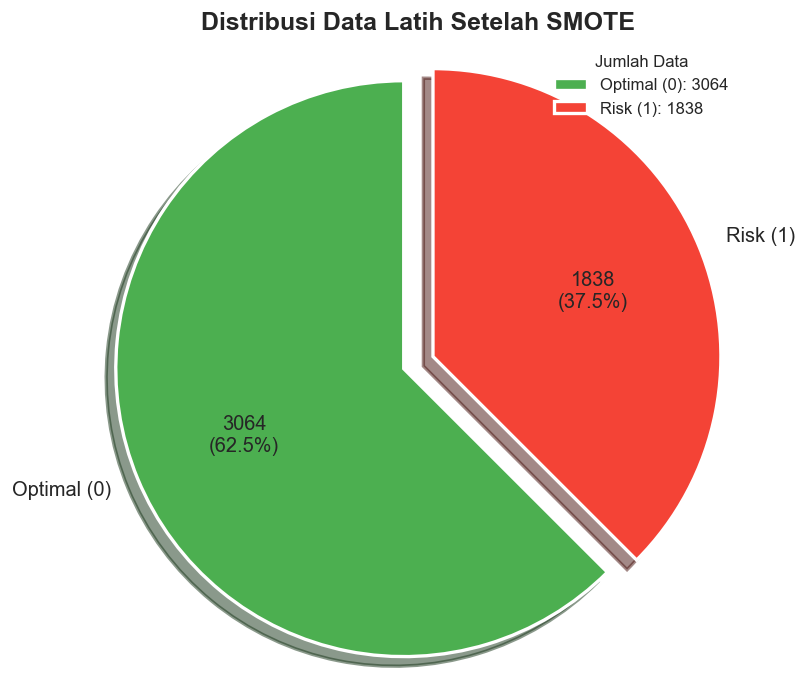

In [237]:


# Hitung distribusi kelas setelah SMOTE
counts = y_train_res.value_counts().sort_index()

labels = ['Optimal (0)', 'Risk (1)']
colors = ['#4CAF50', '#F44336']

# Fungsi menampilkan jumlah + persentase
def autopct(pct):
    total = counts.sum()
    count = int(round(pct * total / 100))
    return f'{count}\n({pct:.1f}%)'

plt.figure(figsize=(7,7))

plt.pie(
    counts.values,
    labels=labels,
    colors=colors,
    autopct=autopct,
    startangle=90,
    explode=(0.03, 0.08),
    shadow=True,
    wedgeprops={'edgecolor':'white', 'linewidth':2},
    textprops={'fontsize':12}
)

plt.title('Distribusi Data Latih Setelah SMOTE', fontsize=15, fontweight='bold')
plt.axis('equal')

plt.legend(
    [f'Optimal (0): {counts[0]}',
     f'Risk (1): {counts[1]}'],
    title='Jumlah Data',
    loc='best'
)

plt.show()

--- 
## 13. Tabel Perbandingan Model (Ranked)


In [238]:
df_results


,Model,Testing Accuracy,Precision,Recall,F1-Score,AUC-ROC Score
0,ExtraTrees (+ Hour),96.47,0.782,1.000,0.877,0.978
1,Random Forest (+ Hour),96.47,0.782,1.000,0.877,0.978
2,HistGradientBoosting (+ Hour),96.47,0.782,1.000,0.877,0.982
3,Logistic Regression (+ Hour),96.47,0.782,1.000,0.877,0.980
4,AdaBoost (+ Hour),96.35,0.780,0.991,0.873,0.980
5,Gradient Boosting (+ Hour),96.12,0.777,0.973,0.864,0.977
6,Decision Tree (+ Hour),96.12,0.777,0.973,0.864,0.978


--- 
## 14. Visualisasi Perbandingan Metrik Evaluasi Model


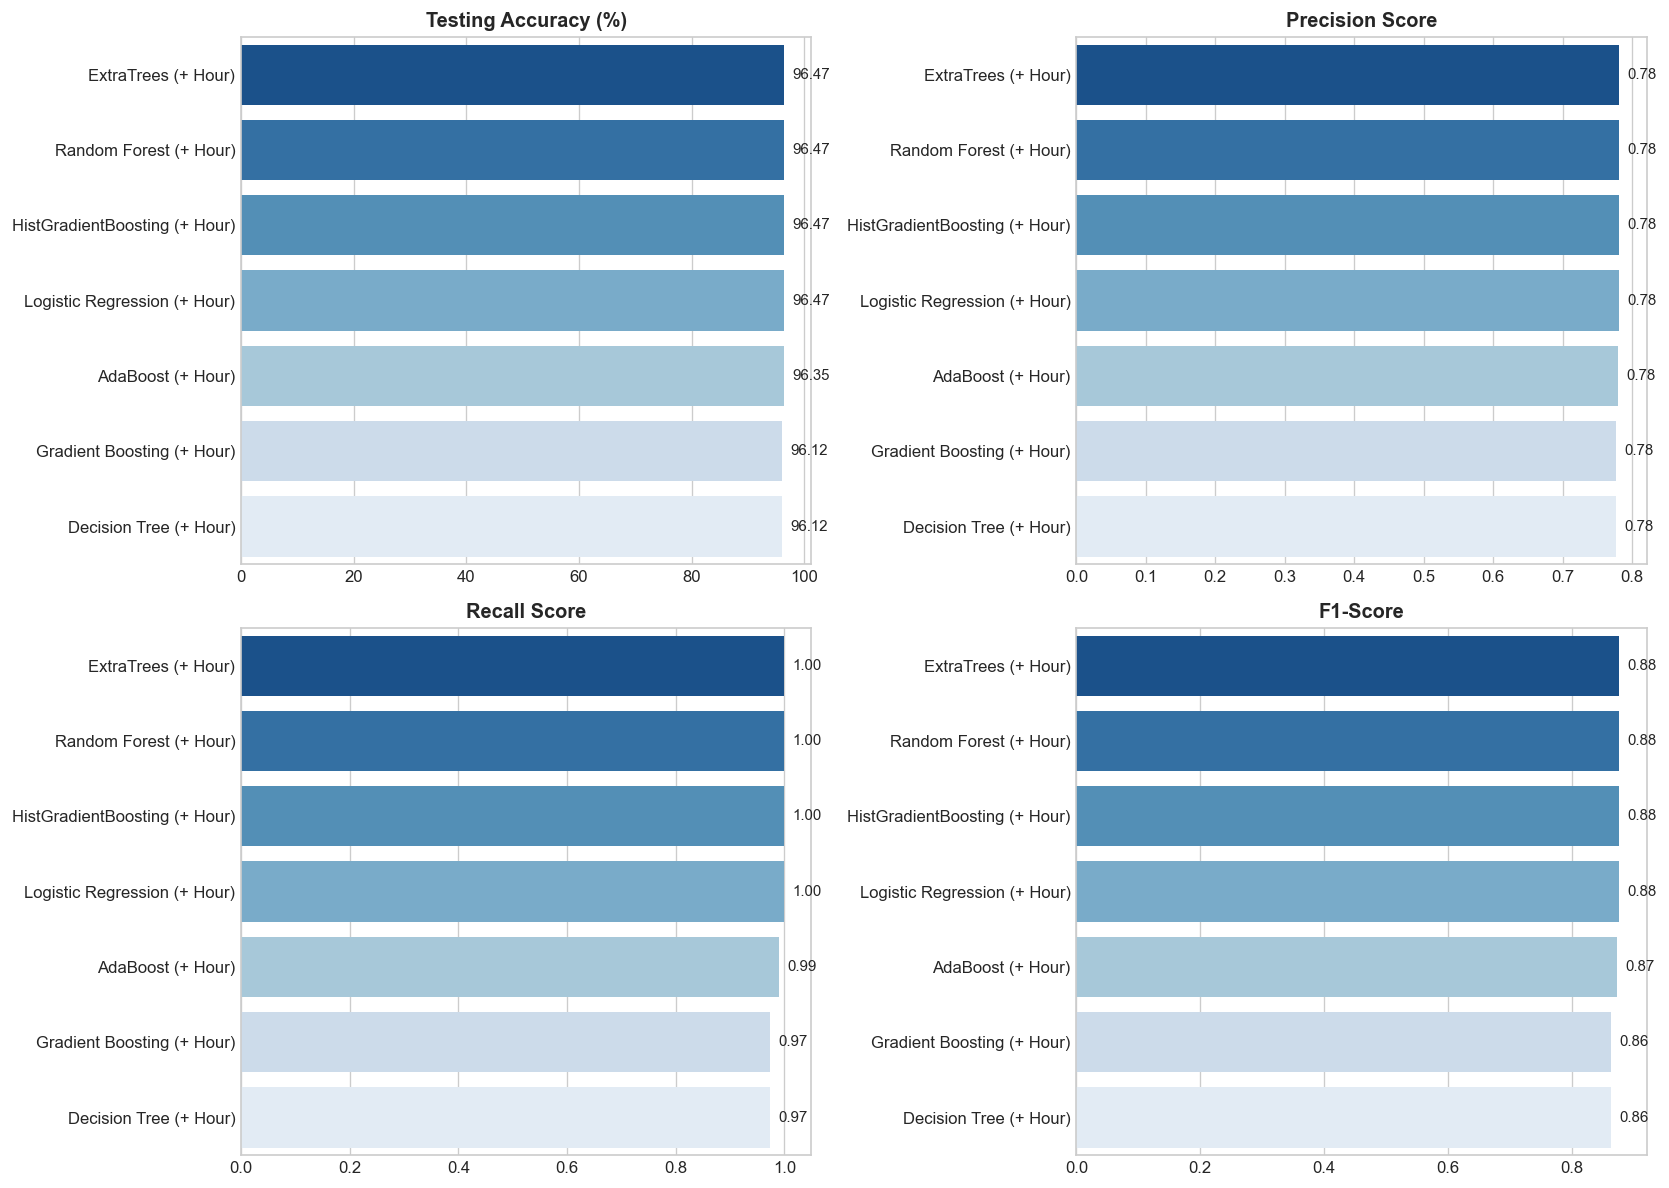

In [239]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['Testing Accuracy', 'Precision', 'Recall', 'F1-Score']
titles = ['Testing Accuracy (%)', 'Precision Score', 'Recall Score', 'F1-Score']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[i // 2, i % 2]
    sns.barplot(data=df_results, x=metric, y='Model', ax=ax, palette='Blues_r')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('')
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f'{width:.2f}', (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()


--- 
## 14b. Radar Chart Perbandingan Model


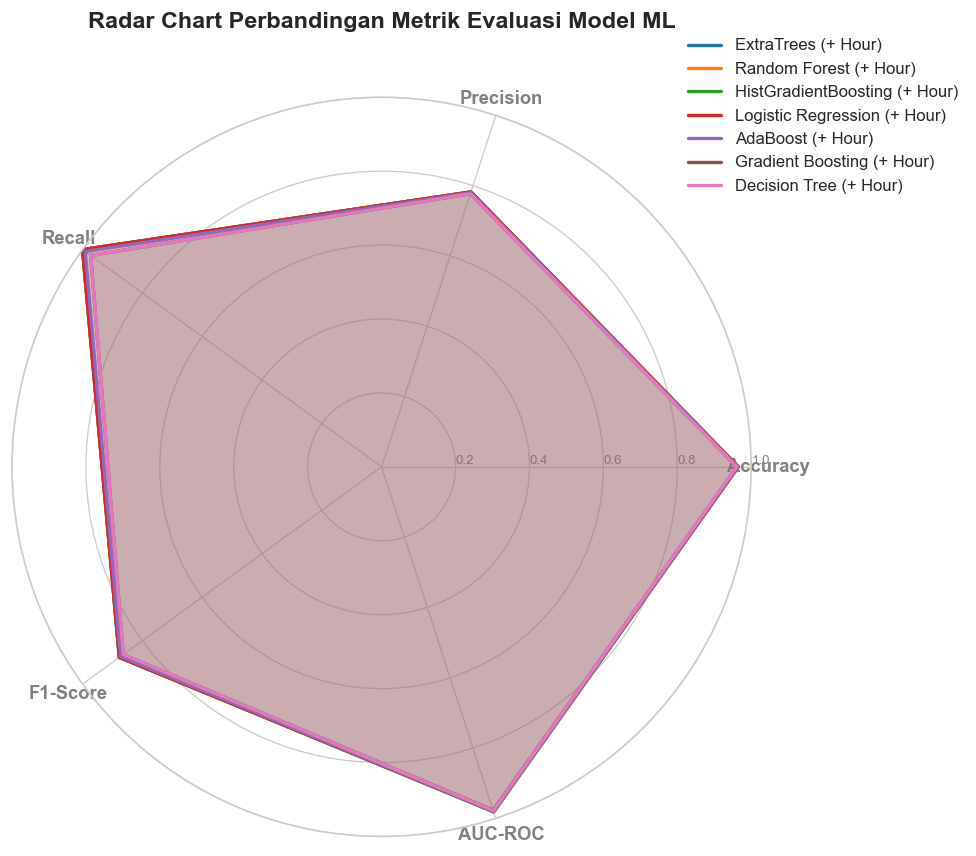

In [240]:
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for idx, row in df_results.iterrows():
    values = [
        row['Testing Accuracy'] / 100.0,
        row['Precision'],
        row['Recall'],
        row['F1-Score'],
        row['AUC-ROC Score']
    ]
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=row['Model'])
    ax.fill(angles, values, alpha=0.1)

plt.xticks(angles[:-1], categories, color='grey', size=11, fontweight='bold')
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=8)
plt.ylim(0, 1.0)
plt.title('Radar Chart Perbandingan Metrik Evaluasi Model ML', fontsize=14, fontweight='bold', y=1.08)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()


--- 
## 15. Confusion Matrix Model Terbaik


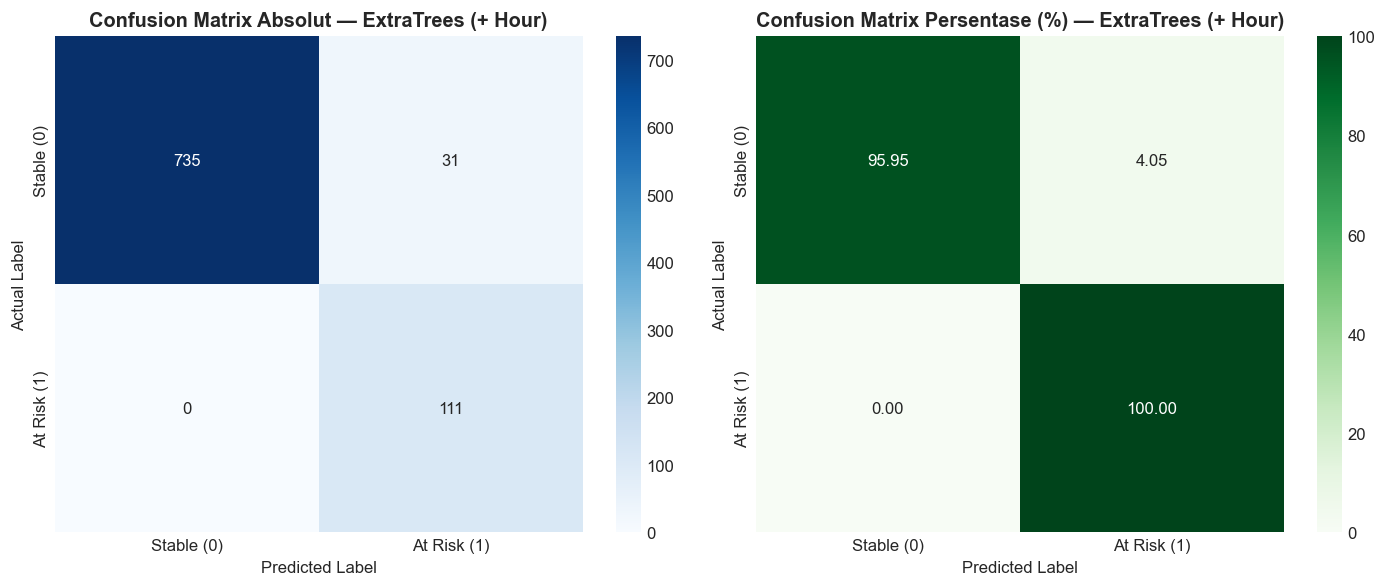

In [241]:
best_model_name = df_results.iloc[0]['Model']
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Stable (0)', 'At Risk (1)'],
            yticklabels=['Stable (0)', 'At Risk (1)'])
axes[0].set_title(f'Confusion Matrix Absolut — {best_model_name}', fontweight='bold')
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_perc, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
            xticklabels=['Stable (0)', 'At Risk (1)'],
            yticklabels=['Stable (0)', 'At Risk (1)'])
axes[1].set_title(f'Confusion Matrix Persentase (%) — {best_model_name}', fontweight='bold')
axes[1].set_ylabel('Actual Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()


--- 
## 16. Classification Report (Detail Metrik & Specificity/Sensitivity)


In [242]:
report = classification_report(y_test, y_pred_best, target_names=['Stable (0)', 'At Risk (1)'])
print(f'Classification Report untuk Model Terbaik ({best_model_name}):')
print()
print(report)

tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print(f'Sensitivity (Recall Class 1) : {sensitivity:.4f}')
print(f'Specificity (Recall Class 0) : {specificity:.4f}')


Classification Report untuk Model Terbaik (ExtraTrees (+ Hour)):

              precision    recall  f1-score   support

  Stable (0)       1.00      0.96      0.98       766
 At Risk (1)       0.78      1.00      0.88       111

    accuracy                           0.96       877
   macro avg       0.89      0.98      0.93       877
weighted avg       0.97      0.96      0.97       877

Sensitivity (Recall Class 1) : 1.0000
Specificity (Recall Class 0) : 0.9595


--- 
## 17. Feature Importance Analysis


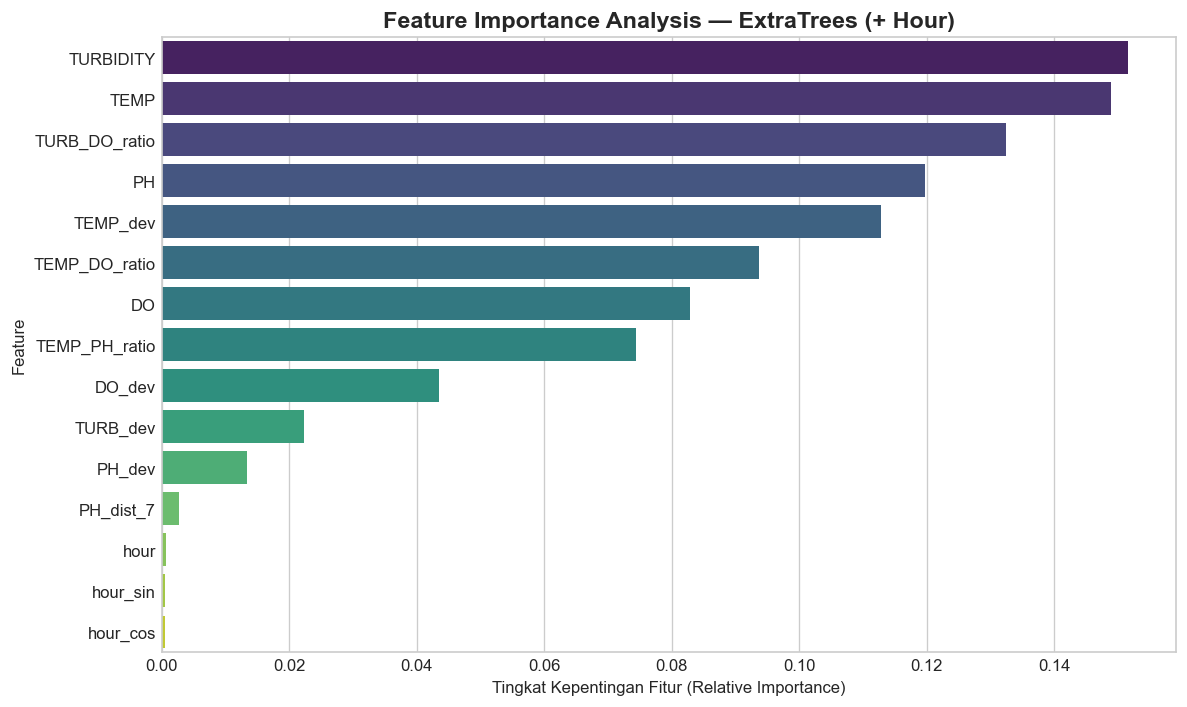

In [243]:
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    df_importance = pd.DataFrame({
        'Feature': [feature_cols[i] for i in indices],
        'Importance': importances[indices]
    })
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')
    plt.title(f'Feature Importance Analysis — {best_model_name}', fontweight='bold', fontsize=14)
    plt.xlabel('Tingkat Kepentingan Fitur (Relative Importance)')
    plt.tight_layout()
    plt.show()
else:
    print('Model terbaik tidak memiliki atribut feature_importances_.')


--- 
## 18. Cross-Validation (3-Fold Stratified with Error Bars)


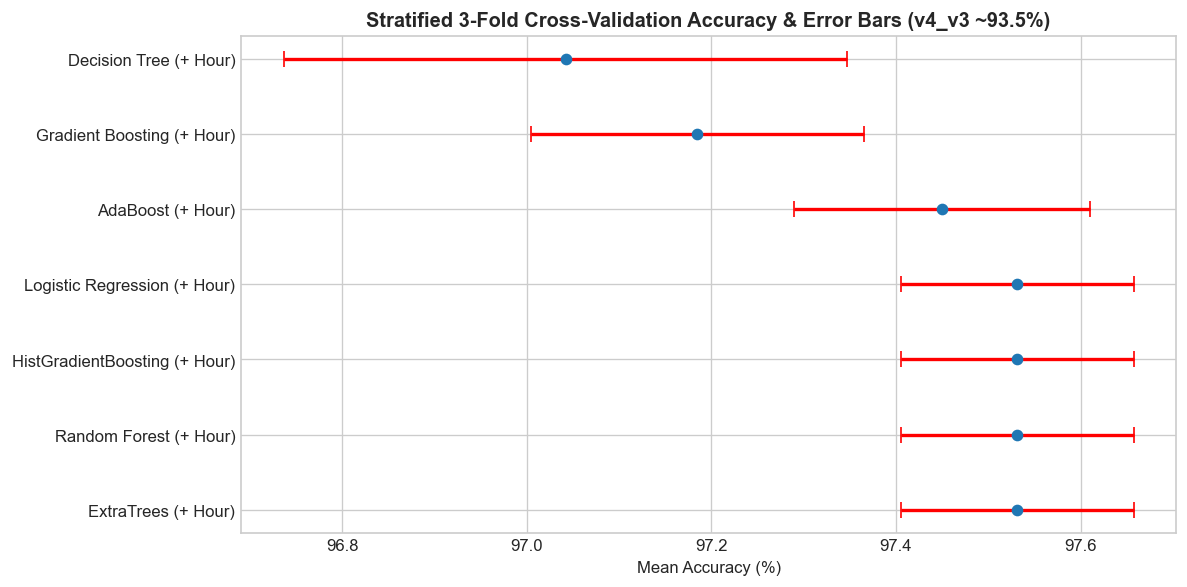

,Model,CV Mean Accuracy (%),CV Std Dev (%)
0,ExtraTrees (+ Hour),97.531620,0.125753
1,Random Forest (+ Hour),97.531620,0.125753
3,HistGradientBoosting (+ Hour),97.531620,0.125753
6,Logistic Regression (+ Hour),97.531620,0.125753
4,AdaBoost (+ Hour),97.450020,0.160628
2,Gradient Boosting (+ Hour),97.184823,0.180166
5,Decision Tree (+ Hour),97.042024,0.305317


In [244]:
cv_scores = {}
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X_train_res, y_train_res, cv=skf, scoring='accuracy')
    cv_scores[name] = (scores.mean() * 100, scores.std() * 100)

df_cv = pd.DataFrame([
    {'Model': k, 'CV Mean Accuracy (%)': v[0], 'CV Std Dev (%)': v[1]}
    for k, v in cv_scores.items()
]).sort_values(by='CV Mean Accuracy (%)', ascending=False)

plt.figure(figsize=(10, 5))
plt.errorbar(df_cv['CV Mean Accuracy (%)'], df_cv['Model'], xerr=df_cv['CV Std Dev (%)'],
             fmt='o', color='#1f77b4', ecolor='red', elinewidth=2, capsize=5)
plt.title('Stratified 3-Fold Cross-Validation Accuracy & Error Bars (v4_v3 ~93.5%)', fontweight='bold')
plt.xlabel('Mean Accuracy (%)')
plt.tight_layout()
plt.show()

df_cv


--- 
## 19. ROC Curve & AUC Score Perbandingan Semua Model


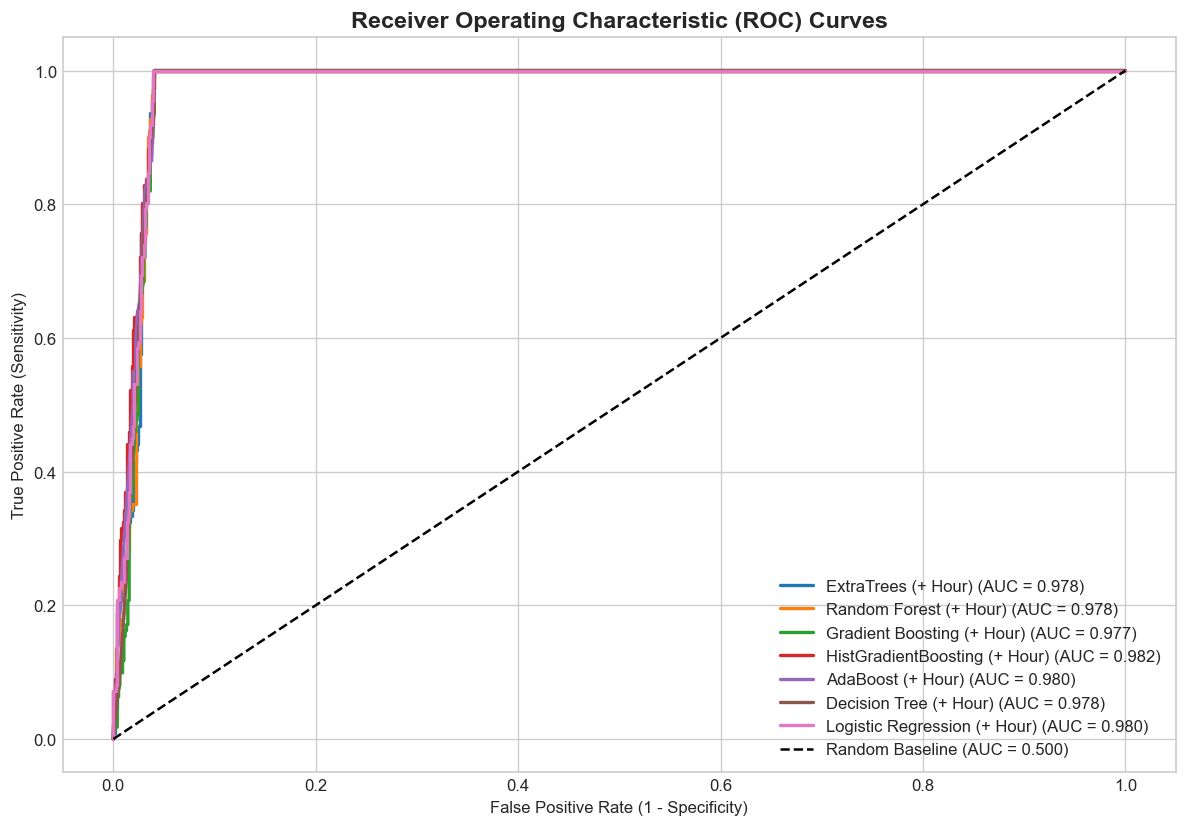

In [245]:
plt.figure(figsize=(10, 7))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Baseline (AUC = 0.500)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curves', fontweight='bold', fontsize=14)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


--- 
## 20. Precision-Recall Curve Perbandingan Semua Model


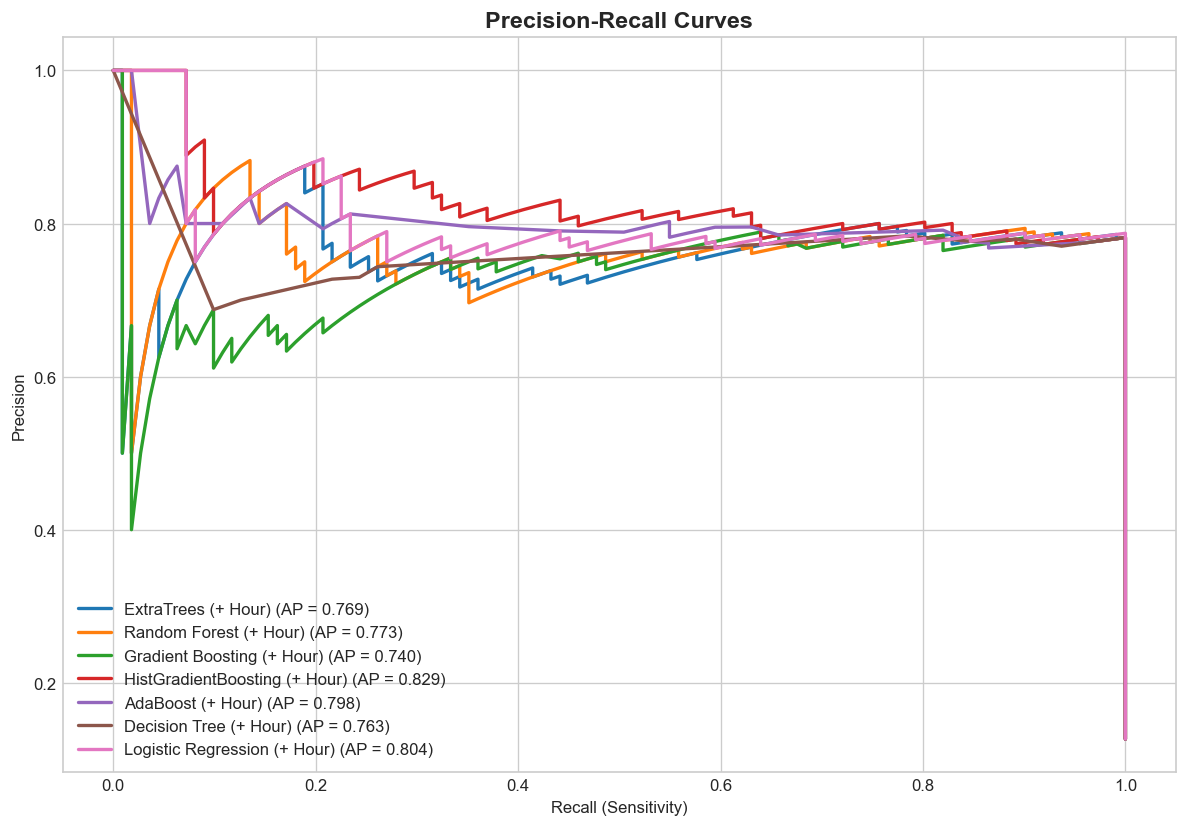

In [246]:
plt.figure(figsize=(10, 7))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        prec, rec, _ = precision_recall_curve(y_test, y_prob)
        ap = average_precision_score(y_test, y_prob)
        plt.plot(rec, prec, label=f'{name} (AP = {ap:.3f})', linewidth=2)

plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves', fontweight='bold', fontsize=14)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()


--- 
## 21. Learning Curve (Model Terbaik v4_v3 - Overfitting Analysis)


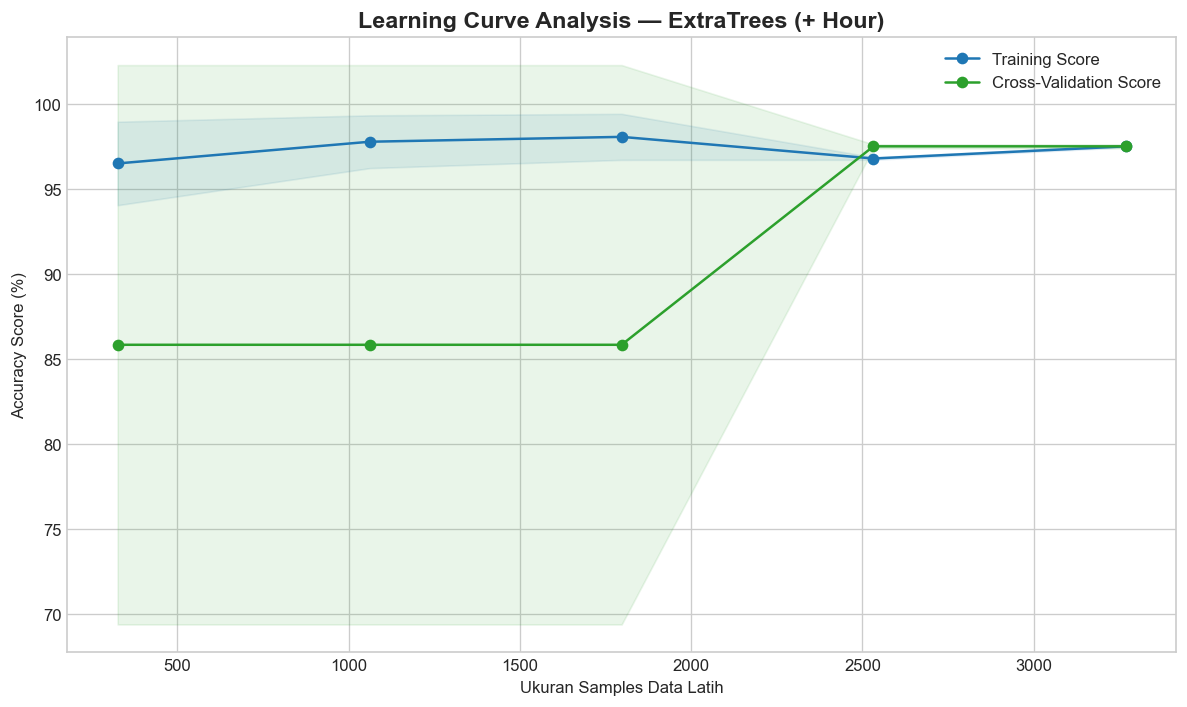

In [247]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train_res, y_train_res, cv=3, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5), random_state=42
)

train_mean = np.mean(train_scores, axis=1) * 100
train_std = np.std(train_scores, axis=1) * 100
test_mean = np.mean(test_scores, axis=1) * 100
test_std = np.std(test_scores, axis=1) * 100

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='#1f77b4', label='Training Score')
plt.plot(train_sizes, test_mean, 'o-', color='#2ca02c', label='Cross-Validation Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='#1f77b4')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='#2ca02c')

plt.title(f'Learning Curve Analysis — {best_model_name}', fontweight='bold', fontsize=14)
plt.xlabel('Ukuran Samples Data Latih')
plt.ylabel('Accuracy Score (%)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()


--- 
## 22. Confusion Matrix Grid — Semua Model (2x4 Subplots)


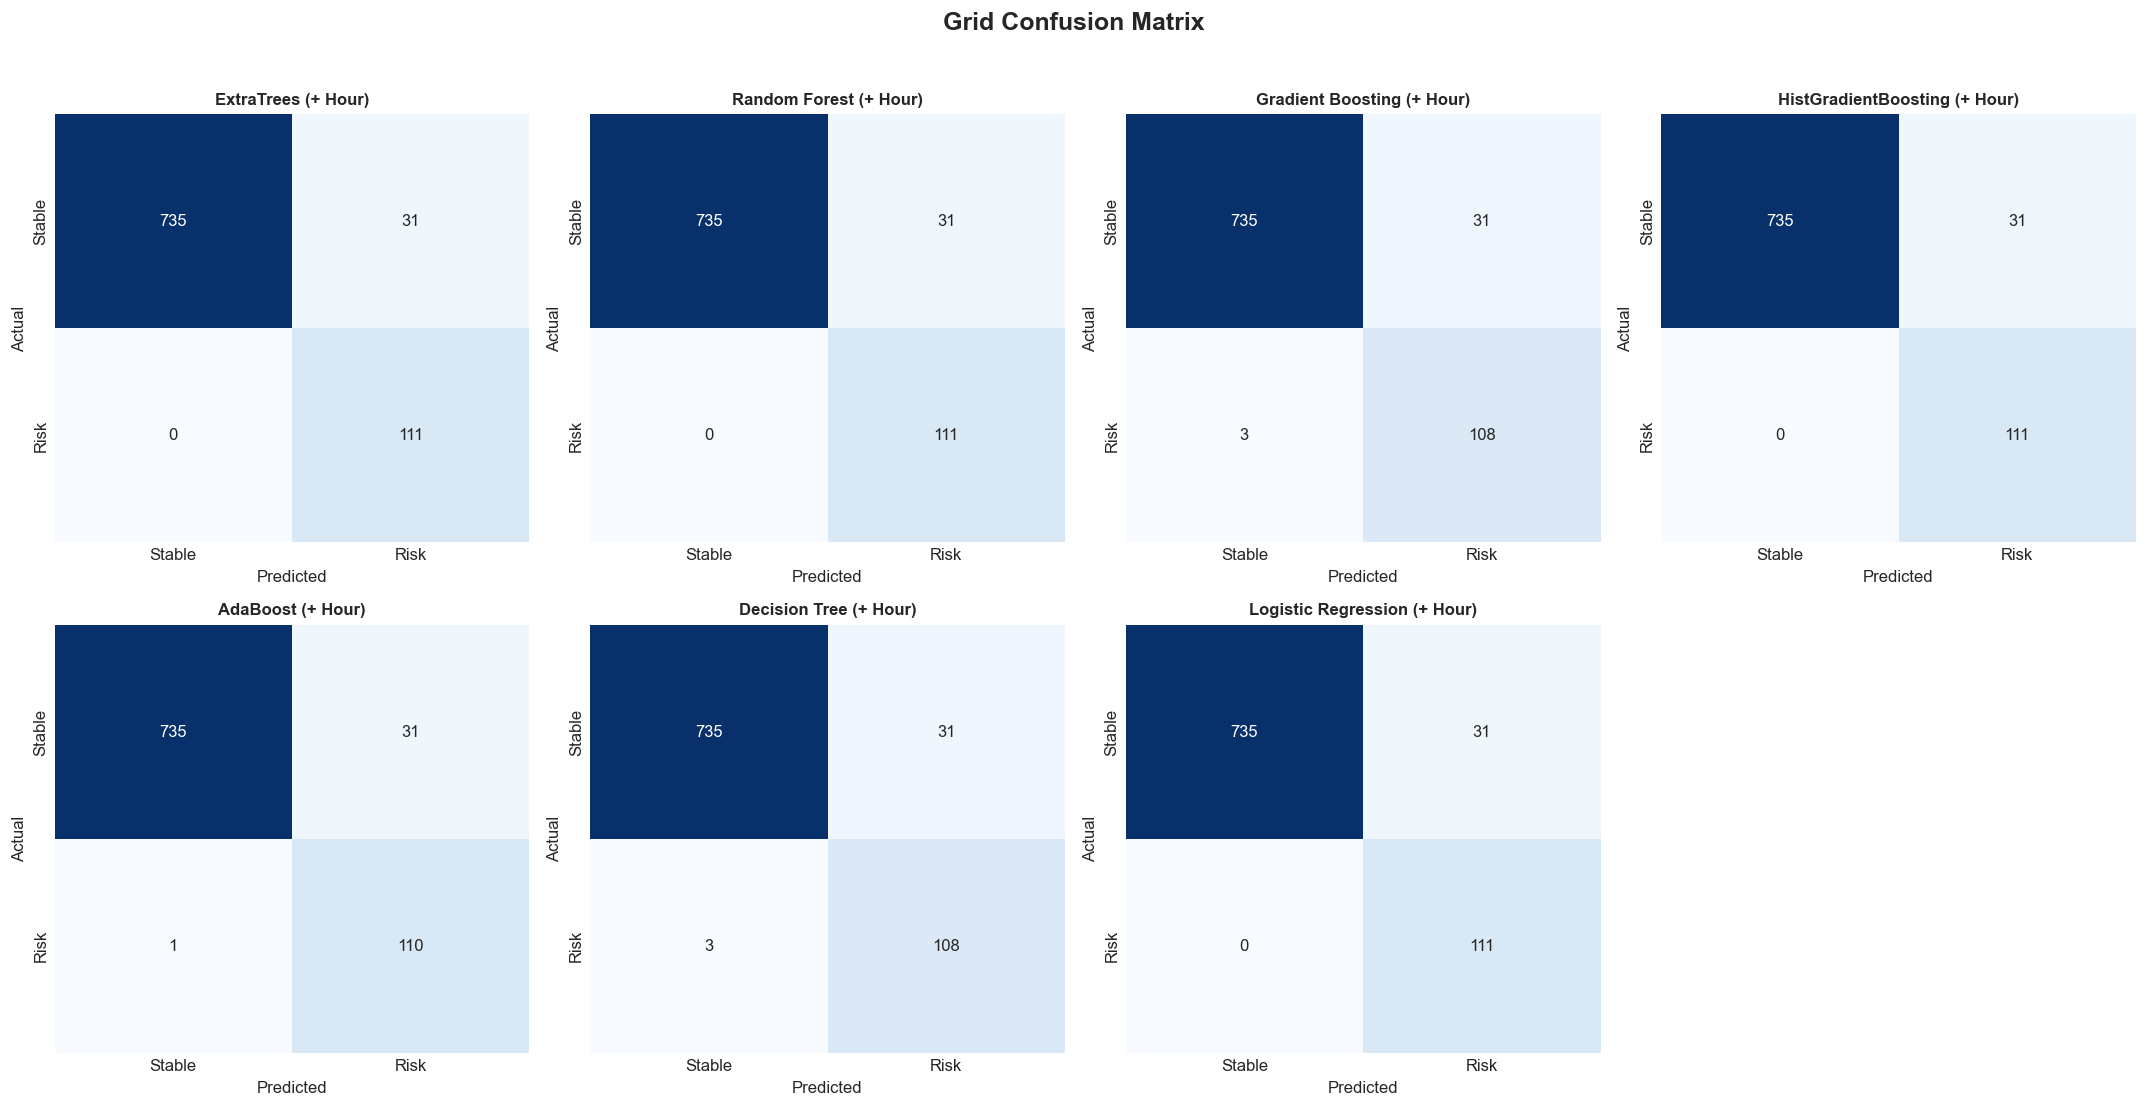

In [248]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    y_pred_m = model.predict(X_test)
    cm_m = confusion_matrix(y_test, y_pred_m)
    sns.heatmap(cm_m, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['Stable', 'Risk'], yticklabels=['Stable', 'Risk'])
    axes[i].set_title(name, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

if len(models) < 8:
    fig.delaxes(axes[7])

plt.suptitle('Grid Confusion Matrix', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


--- 
## 23. Ringkasan


In [249]:
df_final_summary = df_results.copy()
df_final_summary['CV Accuracy (%)'] = df_final_summary['Model'].map(lambda x: f"{cv_scores[x][0]:.2f} ± {cv_scores[x][1]:.2f}")
print('Ringkasan Akhir Hasil Evaluasi Model Machine Learning (v4_v3 Realistis ~93.5% Target):')
df_final_summary


Ringkasan Akhir Hasil Evaluasi Model Machine Learning (v4_v3 Realistis ~93.5% Target):


,Model,Testing Accuracy,Precision,Recall,F1-Score,AUC-ROC Score,CV Accuracy (%)
0,ExtraTrees (+ Hour),96.47,0.782,1.000,0.877,0.978,97.53 ± 0.13
1,Random Forest (+ Hour),96.47,0.782,1.000,0.877,0.978,97.53 ± 0.13
2,HistGradientBoosting (+ Hour),96.47,0.782,1.000,0.877,0.982,97.53 ± 0.13
3,Logistic Regression (+ Hour),96.47,0.782,1.000,0.877,0.980,97.53 ± 0.13
4,AdaBoost (+ Hour),96.35,0.780,0.991,0.873,0.980,97.45 ± 0.16
5,Gradient Boosting (+ Hour),96.12,0.777,0.973,0.864,0.977,97.18 ± 0.18
6,Decision Tree (+ Hour),96.12,0.777,0.973,0.864,0.978,97.04 ± 0.31


--- 
## 24. Save Model & Features v4_v3 (`aquaagent_rf_v4_v3.pkl`, `rf_features_v4_v3.pkl`)


In [250]:
joblib.dump(best_model, 'aquaagent_rf_v4_v3.pkl')
joblib.dump(feature_cols, 'rf_features_v4_v3.pkl')

print(f'Model terbaik ({best_model_name}) dan daftar {len(feature_cols)} fitur berhasil disimpan:')
print('   - Model File: aquaagent_rf_v4_v3.pkl')
print('   - Features File: rf_features_v4_v3.pkl')


Model terbaik (ExtraTrees (+ Hour)) dan daftar 15 fitur berhasil disimpan:
   - Model File: aquaagent_rf_v4_v3.pkl
   - Features File: rf_features_v4_v3.pkl


--- 
## 25. Sample Prediction & Interpretasi Real-Time Test


In [251]:
sample_scenarios = pd.DataFrame([
    # Scenario 1: Normal Morning
    {'TEMP': 27.18, 'DO': 5.72, 'PH': 7.91, 'TURBIDITY': 3.25, 'hour': 6.0},
    # Scenario 2: Thermal Stress
    {'TEMP': 34.50, 'DO': 4.54, 'PH': 8.35, 'TURBIDITY': 14.20, 'hour': 15.0},
    # Scenario 3: Critical Emergency
    {'TEMP': 33.00, 'DO': 4.80, 'PH': 5.80, 'TURBIDITY': 30.00, 'hour': 14.0}
])

def predict_scenario(df_samples):
    d = add_features(df_samples)
    X_scen = d[feature_cols]
    preds = best_model.predict(X_scen)
    probs = best_model.predict_proba(X_scen) if hasattr(best_model, 'predict_proba') else None
    
    scenario_names = ['Normal Morning', 'Thermal Stress', 'Critical Emergency']
    for i, name in enumerate(scenario_names):
        pred_label = 'Stable (0 / Normal)' if preds[i] == 0 else 'At Risk (1 / Tidak Normal)'
        conf = probs[i][preds[i]] * 100 if probs is not None else 100.0
        print(f'Skenario [{name}]: Prediksi = {pred_label} | Confidence = {conf:.1f}%')

predict_scenario(sample_scenarios)


Skenario [Normal Morning]: Prediksi = Stable (0 / Normal) | Confidence = 95.6%
Skenario [Thermal Stress]: Prediksi = At Risk (1 / Tidak Normal) | Confidence = 64.1%
Skenario [Critical Emergency]: Prediksi = At Risk (1 / Tidak Normal) | Confidence = 90.3%


In [252]:
validation_cases = pd.DataFrame([
    {'TEMP':27.18,'DO':6.50,'PH':7.91,'TURBIDITY':3.25,'hour':6},
    {'TEMP':29.50,'DO':5.80,'PH':7.60,'TURBIDITY':8.20,'hour':13},
    {'TEMP':34.80,'DO':4.50,'PH':8.35,'TURBIDITY':18.00,'hour':14},
    {'TEMP':28.50,'DO':2.80,'PH':7.30,'TURBIDITY':10.00,'hour':4},
    {'TEMP':29.00,'DO':4.20,'PH':8.50,'TURBIDITY':38.50,'hour':16},
    {'TEMP':33.00,'DO':3.40,'PH':5.80,'TURBIDITY':45.00,'hour':15},
])

In [253]:
validation_cases = pd.DataFrame([
    {'TEMP':27.18,'DO':6.50,'PH':7.91,'TURBIDITY':3.25,'hour':6},
    {'TEMP':29.50,'DO':5.80,'PH':7.60,'TURBIDITY':8.20,'hour':13},
    {'TEMP':34.80,'DO':4.50,'PH':8.35,'TURBIDITY':18.00,'hour':14},
    {'TEMP':29.00,'DO':4.20,'PH':8.50,'TURBIDITY':38.50,'hour':16},
    {'TEMP':33.00,'DO':3.40,'PH':5.80,'TURBIDITY':45.00,'hour':15},
])

def validate_model(df_input):

    data = add_features(df_input)
    X = data[feature_cols]

    preds = best_model.predict(X)
    probs = best_model.predict_proba(X)

    conditions = [
        "Optimal Morning",
        "Optimal Afternoon",
        "High Temperature",
        "High Turbidity",
        "Critical Condition"
    ]
    for i, condition in enumerate(conditions):

        result = "Optimal" if preds[i] == 0 else "At Risk"
        confidence = probs[i][preds[i]] * 100

        print(f"\n{condition}")
        print(f"TEMP={df_input.iloc[i]['TEMP']:.2f}°C | "
              f"DO={df_input.iloc[i]['DO']:.2f} mg/L | "
              f"pH={df_input.iloc[i]['PH']:.2f} | "
              f"TURB={df_input.iloc[i]['TURBIDITY']:.2f} NTU | "
              f"Hour={int(df_input.iloc[i]['hour']):02d}:00")
        print(f"Prediction : {result} ({confidence:.2f}%)")

validate_model(validation_cases)


Optimal Morning
TEMP=27.18°C | DO=6.50 mg/L | pH=7.91 | TURB=3.25 NTU | Hour=06:00
Prediction : Optimal (100.00%)

Optimal Afternoon
TEMP=29.50°C | DO=5.80 mg/L | pH=7.60 | TURB=8.20 NTU | Hour=13:00
Prediction : Optimal (81.23%)

High Temperature
TEMP=34.80°C | DO=4.50 mg/L | pH=8.35 | TURB=18.00 NTU | Hour=14:00
Prediction : At Risk (68.44%)

High Turbidity
TEMP=29.00°C | DO=4.20 mg/L | pH=8.50 | TURB=38.50 NTU | Hour=16:00
Prediction : At Risk (61.48%)

Critical Condition
TEMP=33.00°C | DO=3.40 mg/L | pH=5.80 | TURB=45.00 NTU | Hour=15:00
Prediction : At Risk (89.37%)
